In [6]:
from langchain_ollama import OllamaLLM
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="minimax-m3:cloud",
    temperature=0
)

In [7]:
from langchain_ollama import OllamaEmbeddings

embedding_model = OllamaEmbeddings(
    model="mxbai-embed-large:latest"
)

In [8]:
from langgraph.graph import StateGraph,END,START
from typing import TypedDict
from pydantic import BaseModel,Field

In [9]:
from langchain_core.documents import Document
from langchain_qdrant import QdrantVectorStore

In [10]:
import requests

GREENHOUSE_COMPANIES = [
    "openai",
    "stripe",
    "notion",
    "airbnb",
    "figma",
    "coinbase"
]

#### 1.Prompt Chaining -Job Application Assistant

In [106]:
class ChainState(TypedDict):
    user_query:str
    job_search:list
    matched_jobs:list
    ranked_jobs:list
    resume_summary:str
    cover_letter:str

##### job search agent

In [107]:
def search_jobs_agent(state:ChainState)->ChainState:
    query = state["user_query"]
    jobs = []

    for company in GREENHOUSE_COMPANIES:

        url = (
            f"https://boards-api.greenhouse.io/v1/"
            f"boards/{company}/jobs?content=true"
        )

        response = requests.get(url)

        if response.status_code != 200:
            continue

        data = response.json()

        for job in data["jobs"]:

            title = job["title"].lower()

            if query in title:

                jobs.append({
                    "company": company,
                    "title": job["title"],
                    "location": job["location"]["name"],
                    "url": job["absolute_url"],
                    "description": job["content"]
                })

    return {**state,"job_search":jobs}

##### matching agent

In [120]:
from qdrant_client import QdrantClient
from langchain_qdrant import QdrantVectorStore

def matching_agent(state: ChainState) -> ChainState:

    client = QdrantClient(path="./qdrant_db")

    vector_store = QdrantVectorStore(
        client=client,
        collection_name="resume",
        embedding=embedding_model
    )

    matched_jobs = []

    for job in state["job_search"]:

        docs = vector_store.similarity_search_with_score(
            job["description"],
            k=4
        )
        
        context = "\n\n".join(
            
            f"""
            Section: {doc.metadata['section']}
            Score: {score}

            Content:
            {doc.page_content}
            """
                for doc, score in docs
            )

        matched_jobs.append(
            {
                "title": job["title"],
                "company": job["company"],
                "resume_context":context,
                "description":job['description']
            }
        )

    return {
        **state,
        "matched_jobs": matched_jobs
    }

##### ranking agent

In [121]:
def ranking_agent(state: ChainState) -> ChainState:

    ranked_jobs = []

    for job in state["matched_jobs"]:

        prompt = f"""
        You are a hiring assistant.

        Resume Information:
        {job["resume_context"]}

        Job Description:
        {job["description"]}

        Evaluate how well the candidate matches the job.

        Return:
        1. Match score (0-100)
        2. Short explanation

        Format:

        Score: <score>

        Explanation:
        <reason>
        """

        response = llm.invoke(prompt)

        ranked_jobs.append({
            "title": job["title"],
            "company": job["company"],
            "description": job["description"],
            "resume_context": job["resume_context"],
            "evaluation": response.content
        })

    return {
        **state,
        "ranked_jobs": ranked_jobs
    }

##### resume summary agent

In [122]:
def generate_resume_summary(state: ChainState)->ChainState:
    if not state["job_search"]:
        return {
            **state,
            "resume_summary": "No matching jobs found."
        }
    prompt=f"""
    You're a resume assistant. read the following job description and summarize
    the key qualifications and experience the ideal candidate should have,phrased as
    if from the perspective of a strong applicant's resume summary.
    
    Job Description:
    {state['ranked_jobs'][0]['description']}
    
    """
    response=llm.invoke(prompt)
    return {**state,"resume_summary":response.content}

##### generate cover letter agent

In [113]:
def generate_cover_letter(state:ChainState)->ChainState:
    if not state["job_search"]:
        return {
            **state,
            "cover_letter": "No matching jobs found."
        }
    prompt=f"""
    You're a cover letter writing assistant. Using the resume summary below,
    write a professional and personalized cover letter for the following job.
    
    Resume Summary:
    {state['resume_summary']}
    
    Job Description:
    {state['ranked_jobs'][0]['description']}
    """
    
    response=llm.invoke(prompt)
    
    return {**state,"cover_letter":response.content}

##### initializing the langgraph workflow

In [123]:
workflow=StateGraph(ChainState)
workflow

In [124]:
workflow.add_node('job_search',search_jobs_agent)
workflow.add_node('matching_agent',matching_agent)
workflow.add_node('ranking_agent',ranking_agent)
workflow.add_node('generate_resume_summary',generate_resume_summary)
workflow.add_node('generate_cover_letter',generate_cover_letter)
workflow.set_entry_point('job_search')
workflow.add_edge('job_search','matching_agent')
workflow.add_edge('matching_agent','ranking_agent')
workflow.add_edge('ranking_agent','generate_resume_summary')
workflow.add_edge('generate_resume_summary','generate_cover_letter')
workflow.set_finish_point('generate_cover_letter')

In [125]:
app=workflow.compile()

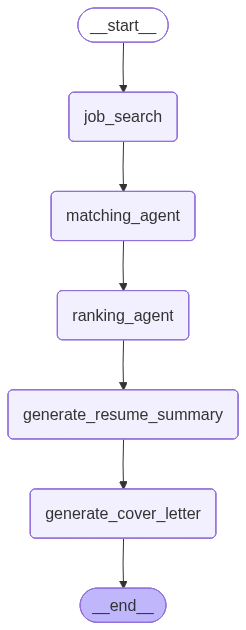

In [126]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [127]:
from langchain_core.documents import Document
from qdrant_client import QdrantClient
from langchain_qdrant import QdrantVectorStore

input_state = {
        "user_query": "data scientist"
}
result=app.invoke(input_state)

In [ ]:
result['job_search']

In [132]:
from pprint import pprint
pprint((result['ranked_jobs']))

[{'company': 'stripe',
  'description': '&lt;h2&gt;&lt;strong&gt;Who we are '
                 '&lt;/strong&gt;&lt;/h2&gt;\n'
                 '&lt;h3&gt;&lt;strong&gt;About '
                 'Stripe&lt;/strong&gt;&lt;/h3&gt;\n'
                 '&lt;p&gt;&lt;span style=&quot;font-weight: '
                 '400;&quot;&gt;Stripe is a financial infrastructure platform '
                 'for businesses. Millions of companies - from the world’s '
                 'largest enterprises to the most ambitious startups - use '
                 'Stripe to accept payments, grow their revenue, and '
                 'accelerate new business opportunities. Our mission is to '
                 'increase the GDP of the internet, and we have a staggering '
                 'amount of work ahead. That means you have an unprecedented '
                 'opportunity to put the global economy within everyone&#39;s '
                 'reach while doing the most important work of your '
                 

In [133]:

pprint(result['resume_summary'])

('# Data Scientist — Resume Summary (Aligned to Stripe Role)\n'
 '\n'
 "**Results-driven Data Scientist with a Master's degree in Computer "
 'Science/Statistics and 3+ years of experience driving data-informed '
 'decisions at scale.** Proven track record of partnering cross-functionally '
 'with Sales, Product, and Data Science teams to translate complex business '
 'questions into actionable insights and measurable outcomes.\n'
 '\n'
 '**Core Competencies & Experience:**\n'
 '\n'
 '- **Statistical & Machine Learning Expertise:** 2+ years applying '
 'statistical models, time series forecasting, and machine learning techniques '
 'to large-scale datasets to predict user and product performance.\n'
 '\n'
 '- **End-to-End Model Productionalization:** 2+ years of experience taking ML '
 'and software solutions from prototype through to production deployment, '
 'including designing and analyzing underlying software architectures.\n'
 '\n'
 '- **Data Engineering & ETL:** 3+ years designi

In [134]:
pprint(result['cover_letter'])

('# Cover Letter: Data Scientist at Stripe\n'
 '\n'
 '---\n'
 '\n'
 'Dear Stripe Hiring Team,\n'
 '\n'
 'When I read Stripe\'s mission to "increase the GDP of the internet," it '
 "immediately resonated with why I've spent the last several years of my "
 'career in data science: the conviction that well-crafted models and analyses '
 "can unlock enormous economic value. I'm writing to apply for the Data "
 'Scientist position, where my background in statistical modeling, '
 'productionalization, and cross-functional partnership aligns directly with '
 'what your team needs.\n'
 '\n'
 "**Direct alignment with the role's core responsibilities:**\n"
 '\n'
 'In my current and previous roles, I have spent the past three years doing '
 'precisely what this position calls for. I have designed and built **ETL data '
 'transformation pipelines in SQL** to power downstream analytics and modeling '
 'initiatives, and I have collaborated closely with **Sales, Product, and '
 'business stakeholders

In [25]:
class graphstate(TypedDict):
    resume_path:str
    resume_text:str
    resume_skills:list[str]
    resume_experience:list[str]
    

In [26]:
from langchain_community.document_loaders import PyPDFLoader
def load_pdf_agent(state:graphstate)->graphstate:
    resume_path=state['resume_path']
    loader = PyPDFLoader(resume_path)
    docs = loader.load()

    text = "\n".join(doc.page_content for doc in docs)
    return {**state,"resume_text":text}

In [27]:
def skill_extraction_agent(state:graphstate)->graphstate:

    prompt = f"""
    Extract the user skills  from this resume.

    Resume:
    {state['resume_text']}

    Return only a Python list.

    Example:
    ["Python","SQL","TensorFlow"]
    """

    response = llm.invoke(prompt)

    return {
        **state,
        "resume_skills": response.content
    }

In [28]:
def experience_extraction_agent(state:graphstate)->graphstate:

    prompt = f"""
    You are an expert experience extractor agent.

    Resume:
        {state['resume_text']}


    Generate 3-5 professional work experience bullet points that demonstrate how these skills were applied in real projects or job responsibilities.

    Requirements:
    - Use strong action verbs.
    - Quantify achievements whenever possible.
    - Keep each bullet concise (1-2 lines).
    - Write in ATS-friendly resume format.

    Return only the bullet points.
    """
    response=llm.invoke(prompt)


    return {
        **state,
        "resume_experience": response.content
    }

In [29]:
def qdrant_store_agent(state:graphstate)->graphstate:

    docs = [

        Document(
            page_content=state["resume_skills"],
            metadata={
                "section":"skills"
            }
        ),

        Document(
            page_content=state["resume_experience"],
            metadata={
                "section":"experience"
            }
        )

    ]

    QdrantVectorStore.from_documents(
        docs,
        embedding_model,
        path="./qdrant_db",
        collection_name="resume"
    )

    return state

In [30]:
workflow=StateGraph(graphstate)
workflow

In [31]:

workflow.add_node('load_pdf_agent',load_pdf_agent)
workflow.add_node('qdrant_store_agent',qdrant_store_agent)
workflow.add_node('skill_extraction_agent',skill_extraction_agent)
workflow.add_node('experience_extraction_agent',experience_extraction_agent)
workflow.set_entry_point('load_pdf_agent')
workflow.add_edge('load_pdf_agent','skill_extraction_agent')
workflow.add_edge('skill_extraction_agent','experience_extraction_agent')
workflow.add_edge('experience_extraction_agent','qdrant_store_agent')
workflow.set_finish_point('qdrant_store_agent')

In [32]:
app=workflow.compile()

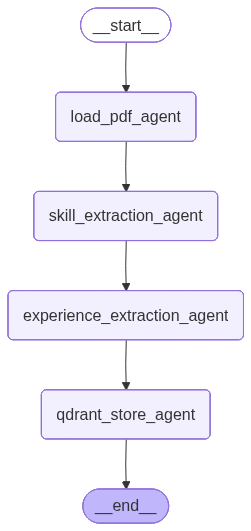

In [33]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [34]:
input_state = {
        "resume_path": "data_scientist_resume_sample.pdf"
}
result=app.invoke(input_state)